## Importaciones

In [25]:
from __future__ import annotations

import time
from dataclasses import dataclass
from typing import Final

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt


In [5]:
BINANCE_BASE_URL: Final[str] = "https://api.binance.com"
KLINES_ENDPOINT: Final[str] = "/api/v3/klines"
START_DATE: Final[str] = "2023-03-01 00:00:00"
FINAL_DATE: Final[str] = "2026-03-01 00:00:00"

## Descarga de datos

Elegimos descarga de datos de Bitcoin desde la API de Binance. La temporalidad de los datos será de 5 minutos.

In [6]:
def download_btc_5m_simple(
    start: str = START_DATE,
    end: str = FINAL_DATE,
    symbol: str = "BTCUSDT",
    interval: str = "5m",
) -> pd.DataFrame:
    """
    Descarga velas de Binance y devuelve un DataFrame sencillo con:
    open_time, open, high, low, close, volume
    """
    start_ts = pd.Timestamp(start, tz="UTC")
    end_ts = pd.Timestamp(end, tz="UTC")

    if start_ts >= end_ts:
        raise ValueError("start debe ser anterior a end")

    start_ms = int(start_ts.timestamp() * 1000)
    end_ms = int(end_ts.timestamp() * 1000)
    step_ms = 5 * 60 * 1000  # 5 minutos

    rows_all = []

    with requests.Session() as session:
        current_start = start_ms

        while current_start < end_ms:
            response = session.get(
                f"{BINANCE_BASE_URL}{KLINES_ENDPOINT}",
                params={
                    "symbol": symbol,
                    "interval": interval,
                    "startTime": current_start,
                    "endTime": end_ms,
                    "limit": 1000,
                },
                timeout=30,
            )
            response.raise_for_status()
            rows = response.json()

            if not rows:
                break

            rows_all.extend(rows)

            last_open_time = int(rows[-1][0])
            current_start = last_open_time + step_ms

            time.sleep(0.15)

    df = pd.DataFrame(
        rows_all,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "quote_asset_volume",
            "number_of_trades",
            "taker_buy_base_volume",
            "taker_buy_quote_volume",
            "ignore",
        ],
    )

    if df.empty:
        raise ValueError("No se descargaron datos")

    df = df[["open_time", "open", "high", "low", "close", "volume"]].copy()

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)

    numeric_cols = ["open", "high", "low", "close", "volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)

    df = df.drop_duplicates(subset="open_time")
    df = df.sort_values("open_time").reset_index(drop=True)

    return df

In [7]:
df_btc = download_btc_5m_simple()
print(df_btc.head())
print(df_btc.shape)

                  open_time      open      high       low     close     volume
0 2023-03-01 00:00:00+00:00  23141.57  23178.71  23130.25  23178.71  990.65778
1 2023-03-01 00:05:00+00:00  23178.03  23183.13  23118.56  23120.06  826.75617
2 2023-03-01 00:10:00+00:00  23120.06  23171.67  23116.07  23159.91  858.93792
3 2023-03-01 00:15:00+00:00  23160.83  23185.64  23158.02  23183.94  705.74922
4 2023-03-01 00:20:00+00:00  23183.94  23219.99  23172.16  23201.88  934.12131
(315633, 6)


## Rellenamos gaps

Rellenamos gaps con ffil y volumen en 0 si no había dato.

In [10]:
def clean_gaps(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detecta gaps y los rellena.
    """
    df = df.copy()

    # Aseguramos orden temporal
    df = df.sort_values("open_time")

    # Usamos open_time como índice
    df = df.set_index("open_time")

    # Frecuencia esperada (5 minutos)
    full_index = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq="5min",
        tz="UTC"
    )

    # Reindex para detectar gaps
    df = df.reindex(full_index)

    # Marcar gaps
    df["is_gap"] = df["close"].isna()

    # Rellenar precios con último valor conocido
    price_cols = ["open", "high", "low", "close"]
    df[price_cols] = df[price_cols].ffill()

    # Volumen a 0 en gaps
    df["volume"] = df["volume"].fillna(0)

    df = df.reset_index().rename(columns={"index": "open_time"})

    return df

In [17]:
df_clean = clean_gaps(df_btc)

print(df_clean["is_gap"].sum())
print(df_clean[df_clean["is_gap"]]["open_time"].min(), df_clean[df_clean["is_gap"]]["open_time"].max())

16
2023-03-24 12:40:00+00:00 2023-03-24 13:55:00+00:00


Parece que todos los gaps están en el día 2023 03 24 entre las horas 12:40 y 13:55. Cuadra con una interrupción real de Binance Spot durante ese período.

En realidad la parada fue desde las 11:27, vamos a examinar.

In [19]:
start = "2023-03-24 11:27:00"
end = "2023-03-24 12:40:00"

df_window = df_clean[
    (df_clean["open_time"] >= start) &
    (df_clean["open_time"] <= end)
]

print(df_window)

                     open_time     open     high      low    close  volume  \
6762 2023-03-24 11:30:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6763 2023-03-24 11:35:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6764 2023-03-24 11:40:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6765 2023-03-24 11:45:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6766 2023-03-24 11:50:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6767 2023-03-24 11:55:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6768 2023-03-24 12:00:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6769 2023-03-24 12:05:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6770 2023-03-24 12:10:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6771 2023-03-24 12:15:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6772 2023-03-24 12:20:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0   
6773 2023-03-24 12:25:00+00:00  28080.0  28080.0  28080.0  28080

In [20]:
start = "2023-03-24 11:27:00"
end = "2023-03-24 12:40:00"

df_window_btc = df_btc[
    (df_btc["open_time"] >= start) &
    (df_btc["open_time"] <= end)
]

print(df_window_btc)

                     open_time     open     high      low    close  volume
6762 2023-03-24 11:30:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6763 2023-03-24 11:35:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6764 2023-03-24 11:40:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6765 2023-03-24 11:45:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6766 2023-03-24 11:50:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6767 2023-03-24 11:55:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6768 2023-03-24 12:00:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6769 2023-03-24 12:05:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6770 2023-03-24 12:10:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6771 2023-03-24 12:15:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6772 2023-03-24 12:20:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6773 2023-03-24 12:25:00+00:00  28080.0  28080.0  28080.0  28080.0     0.0
6774 2023-03-24 12:30:00+

Se ve que Binance ya rellenó esos huecos anteriores.

In [22]:
print(df_clean[df_clean['volume'] == 0]['open_time'].min(), df_clean[df_clean['volume'] == 0]['open_time'].max())

2023-03-24 11:30:00+00:00 2023-03-24 13:55:00+00:00


Perfecto y ese es el hueco

## Calculamos retornos

Calculamos retornos simple y logarítmicos

In [23]:
def compute_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detecta gaps, los rellena y calcula retornos.
    """
    df = df.copy()

    # Aseguramos orden temporal
    df = df.sort_values("open_time")

    # Usamos open_time como índice
    df = df.set_index("open_time")

    # Retornos simples
    df["ret_simple"] = df["close"].pct_change()

    # Retornos logarítmicos
    df["ret_log"] = np.log(df["close"]).diff()

    df = df.reset_index().rename(columns={"index": "open_time"})

    return df

In [24]:
df_clean = compute_returns(df_clean)

Veamos gráfico mínimo

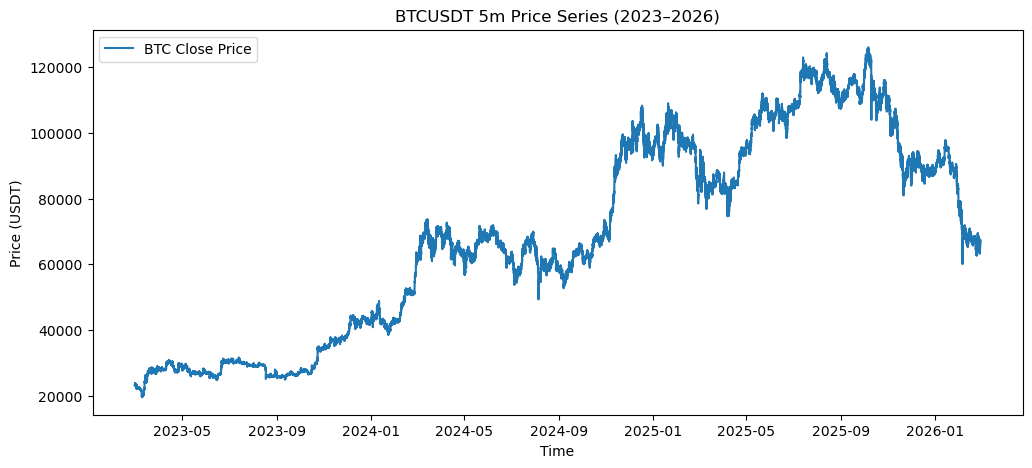

In [26]:
plt.figure(figsize=(12,5))

plt.plot(df_clean["open_time"], df_clean["close"], label="BTC Close Price")

plt.title("BTCUSDT 5m Price Series (2023–2026)")
plt.xlabel("Time")
plt.ylabel("Price (USDT)")
plt.legend()

plt.show()